In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# define the processed dataset path
dataset_path = "../data/processed/spi_features.csv"


# load the dataset
df = pd.read_csv(dataset_path)


# display basic information
print("Dataset shape:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())

Dataset shape: (500, 19)

Columns:
['file', 'total_samples', 'duration_us', 'clock_frequency_khz', 'clock_period_us', 'frame_length_bits', 'command', 'expected_response', 'observed_response', 'response_match', 'bit_order_error', 'miso_stuck_high', 'miso_stuck_low', 'clock_glitch', 'response_delay_us', 'timeout_detected', 'miso_transition_count', 'mosi_transition_count', 'failure_type']


In [2]:
# display the first five rows
df.head()

,file,total_samples,duration_us,clock_frequency_khz,clock_period_us,frame_length_bits,command,expected_response,observed_response,response_match,bit_order_error,miso_stuck_high,miso_stuck_low,clock_glitch,response_delay_us,timeout_detected,miso_transition_count,mosi_transition_count,failure_type
0,capture_0001.csv,16,75.000,100.0,10.000,8,0x06,0xAA,NaN,0,0,0,0,0,NaN,0,0,2,MISSING_ACK
1,capture_0002.csv,32,201.299,77.0,12.987,16,0x0A,0xAA,0xFF,0,0,1,0,0,0.0,0,0,4,MISO_STUCK_HIGH
2,capture_0003.csv,32,201.299,77.0,12.987,16,0x0A,0xAA,0xFF,0,0,1,0,0,0.0,0,0,4,MISO_STUCK_HIGH
3,capture_0004.csv,40,78.000,250.0,4.000,20,0x06,0xAA,0xFF,0,0,1,0,0,0.0,1,0,2,SPI_TIMEOUT
4,capture_0005.csv,36,70.000,250.0,4.000,18,0x05,0xAA,0xAA,1,0,0,0,0,0.0,0,8,3,FRAME_LENGTH_ERROR


In [3]:
# inspect data types and missing values
print(df.info())

print()
print("Missing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   file                   500 non-null    str    
 1   total_samples          500 non-null    int64  
 2   duration_us            500 non-null    float64
 3   clock_frequency_khz    500 non-null    float64
 4   clock_period_us        500 non-null    float64
 5   frame_length_bits      500 non-null    int64  
 6   command                500 non-null    str    
 7   expected_response      500 non-null    str    
 8   observed_response      432 non-null    str    
 9   response_match         500 non-null    int64  
 10  bit_order_error        500 non-null    int64  
 11  miso_stuck_high        500 non-null    int64  
 12  miso_stuck_low         500 non-null    int64  
 13  clock_glitch           500 non-null    int64  
 14  response_delay_us      458 non-null    float64
 15  timeout_detected 

In [4]:
# count captures for each failure type
failure_counts = df["failure_type"].value_counts()

print(failure_counts)

failure_type
BIT_ORDER_ERROR       57
MISO_STUCK_HIGH       55
MISO_STUCK_LOW        48
NORMAL                44
GLITCHED_CLOCK        43
MISSING_ACK           42
SPI_TIMEOUT           37
FRAME_LENGTH_ERROR    37
DELAYED_RESPONSE      37
CLOCK_TOO_SLOW        36
WRONG_RESPONSE        35
CLOCK_TOO_FAST        29
Name: count, dtype: int64


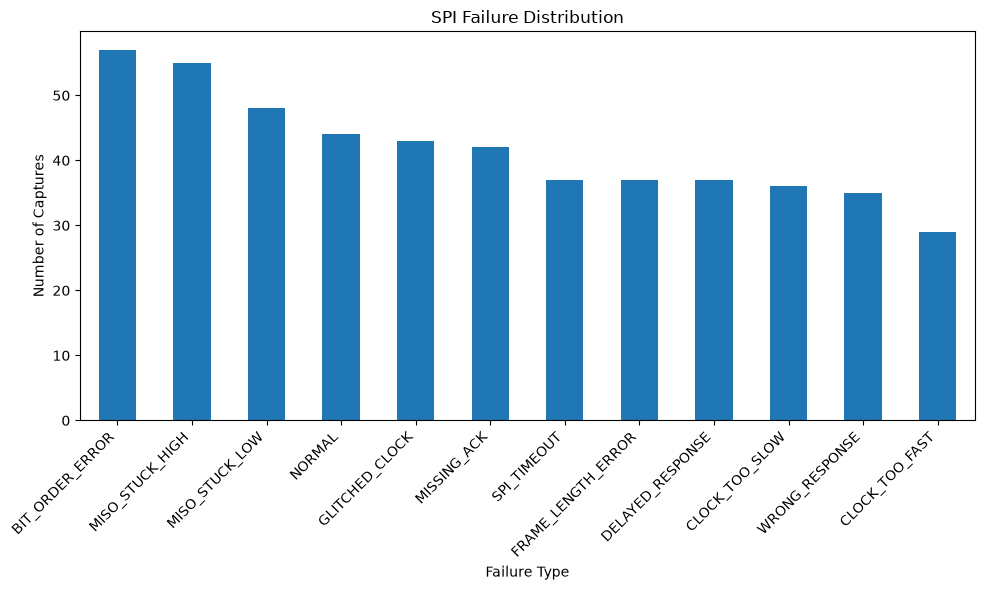

In [5]:
# plot the number of captures per failure type
plt.figure(figsize=(10, 6))

failure_counts.plot(kind="bar")

plt.xlabel("Failure Type")
plt.ylabel("Number of Captures")
plt.title("SPI Failure Distribution")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [6]:
# compare important features across failure types
feature_summary = df.groupby("failure_type")[
    [
        "clock_frequency_khz",
        "clock_period_us",
        "frame_length_bits",
        "response_delay_us",
        "timeout_detected",
        "miso_transition_count",
        "mosi_transition_count",
        "clock_glitch",
        "bit_order_error",
        "miso_stuck_high",
        "miso_stuck_low"
    ]
].mean()

feature_summary.round(2)

,clock_frequency_khz,clock_period_us,frame_length_bits,response_delay_us,timeout_detected,miso_transition_count,mosi_transition_count,clock_glitch,bit_order_error,miso_stuck_high,miso_stuck_low
failure_type,,,,,,,,,,,
BIT_ORDER_ERROR,136.67,9.26,16.00,0.00,0.0,7.00,3.16,0.0,1.0,0.0,0.0
CLOCK_TOO_FAST,706.95,1.54,16.00,0.00,0.0,8.00,3.07,0.0,0.0,0.0,0.0
CLOCK_TOO_SLOW,10.28,123.61,16.00,0.00,0.0,8.00,2.97,0.0,0.0,0.0,0.0
DELAYED_RESPONSE,138.08,9.43,16.00,53.78,0.0,8.00,3.19,0.0,0.0,0.0,0.0
FRAME_LENGTH_ERROR,137.76,9.10,15.41,0.00,0.0,6.92,3.03,0.0,0.0,0.0,0.0
GLITCHED_CLOCK,144.30,8.95,16.00,0.00,0.0,8.00,2.91,1.0,0.0,0.0,0.0
MISO_STUCK_HIGH,129.40,9.61,16.00,0.00,0.0,0.00,3.07,0.0,0.0,1.0,0.0
MISO_STUCK_LOW,130.56,9.68,16.00,0.00,0.0,1.00,3.10,0.0,0.0,0.0,1.0
MISSING_ACK,144.52,8.71,8.00,NaN,0.0,0.00,2.88,0.0,0.0,0.0,0.0
